<a href="https://colab.research.google.com/github/Naro-Kuoch/ANN-Lecture/blob/main/TP1_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective of this TP is to practice building neural network using pytorch for binary classification.

In [42]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,TensorDataset, DataLoader
from tqdm import tqdm

# Seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.target

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


array([[<Axes: title={'center': 'mean radius'}>,
        <Axes: title={'center': 'mean texture'}>,
        <Axes: title={'center': 'mean perimeter'}>,
        <Axes: title={'center': 'mean area'}>,
        <Axes: title={'center': 'mean smoothness'}>,
        <Axes: title={'center': 'mean compactness'}>],
       [<Axes: title={'center': 'mean concavity'}>,
        <Axes: title={'center': 'mean concave points'}>,
        <Axes: title={'center': 'mean symmetry'}>,
        <Axes: title={'center': 'mean fractal dimension'}>,
        <Axes: title={'center': 'radius error'}>,
        <Axes: title={'center': 'texture error'}>],
       [<Axes: title={'center': 'perimeter error'}>,
        <Axes: title={'center': 'area error'}>,
        <Axes: title={'center': 'smoothness error'}>,
        <Axes: title={'center': 'compactness error'}>,
        <Axes: title={'center': 'concavity error'}>,
        <Axes: title={'center': 'concave points error'}>],
       [<Axes: title={'center': 'symmetry error'}>

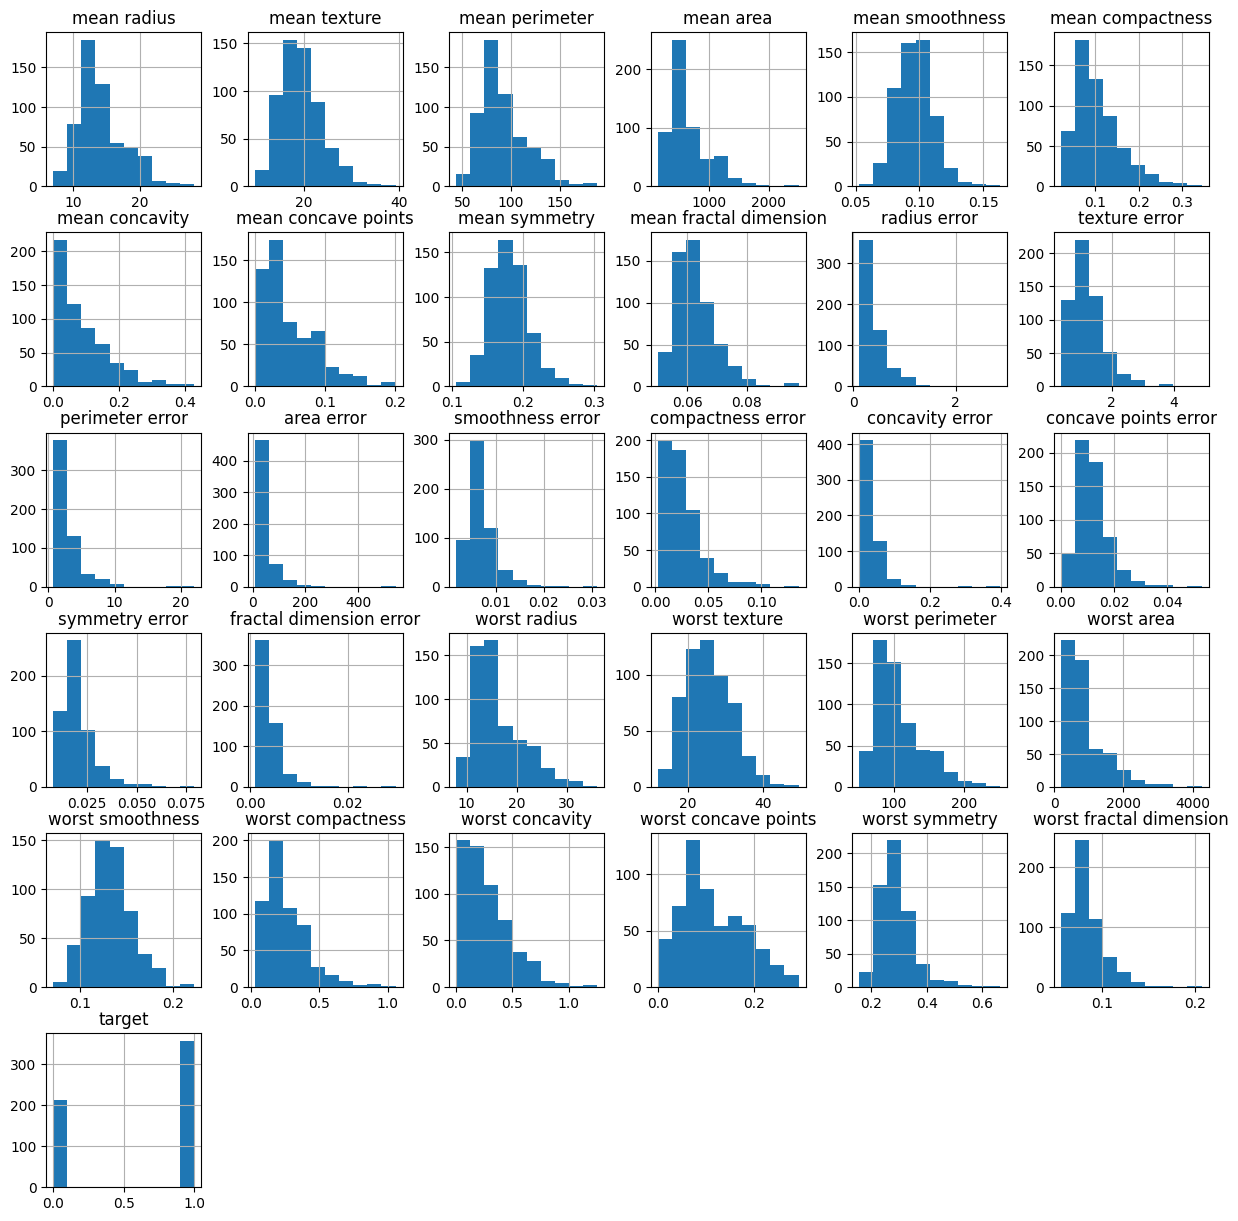

In [8]:
df.hist(figsize=(15,15))

<Axes: xlabel='target', ylabel='count'>

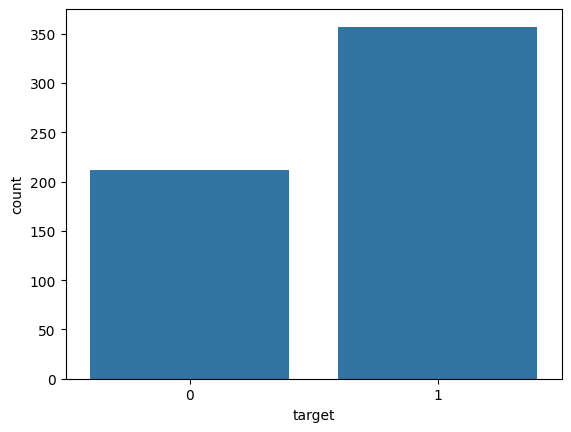

In [9]:
sns.countplot(x='target', data=df)

<Axes: >

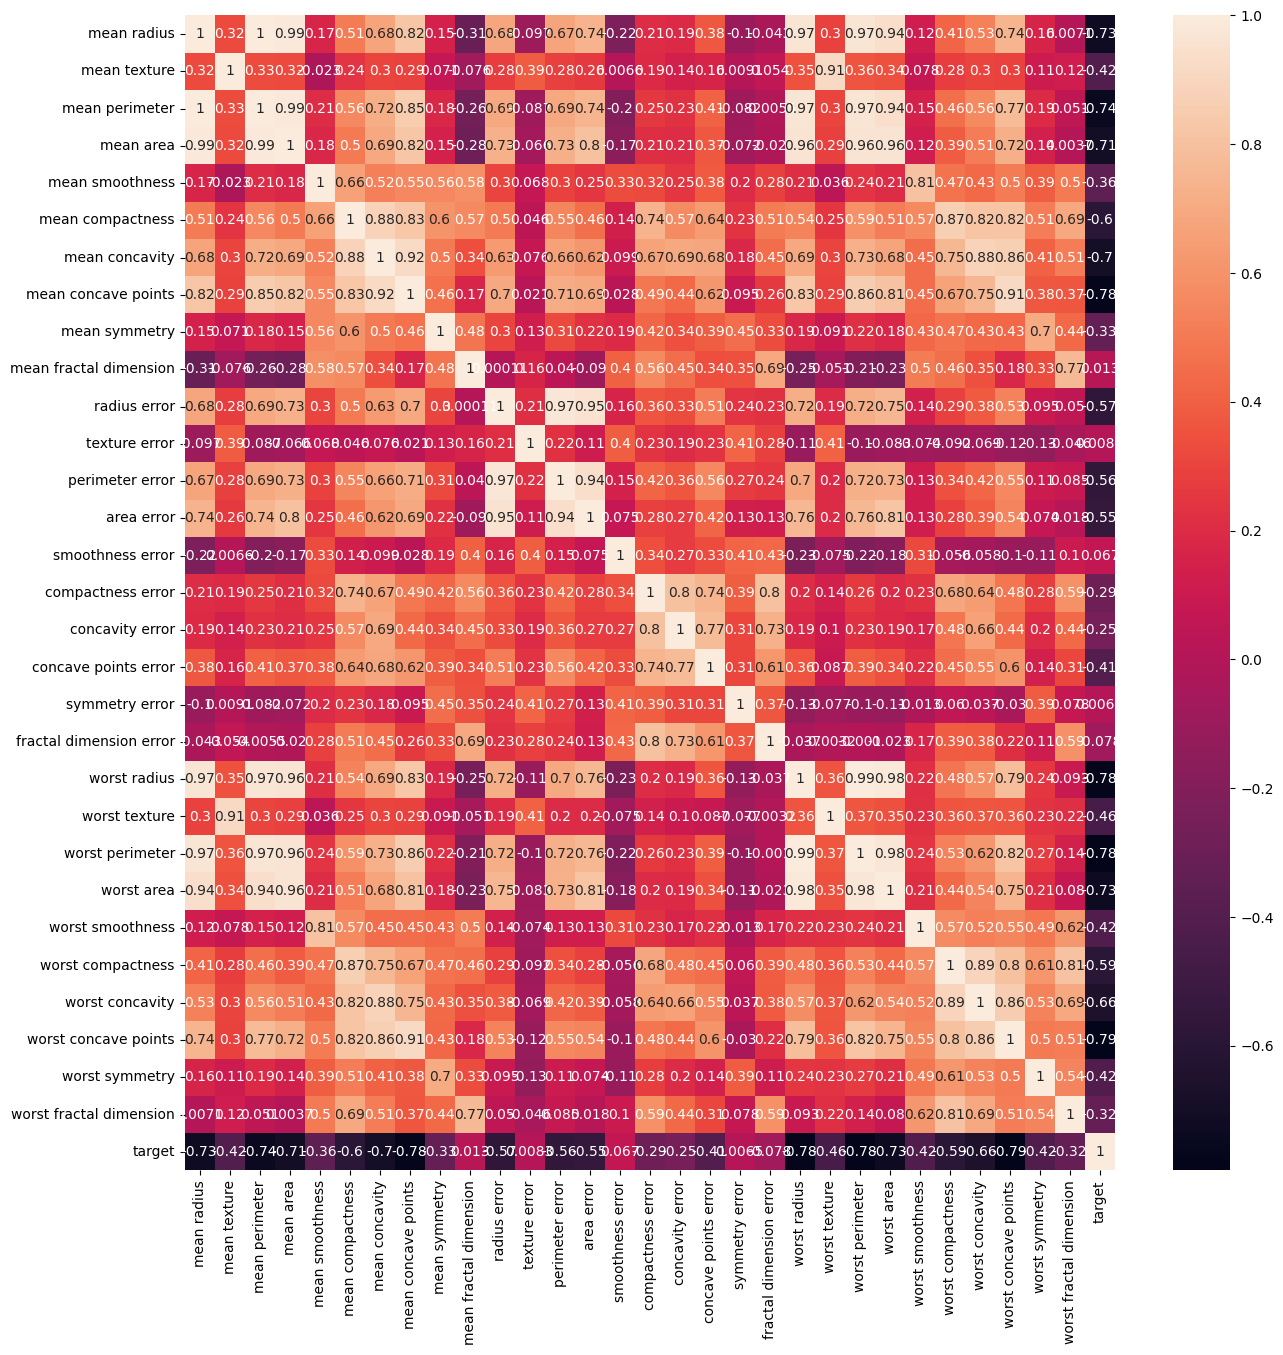

In [10]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True)

# Splitting dataset

In [23]:
x = df.drop('target',axis=1).values
y = df.target.values
print("x: ",type(x),x.dtype)
print("y: ",type(y),y.dtype)
x.shape, y.shape

x:  <class 'numpy.ndarray'> float64
y:  <class 'numpy.ndarray'> int64


((569, 30), (569,))

In [35]:
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.2,random_state=RANDOM_STATE)
x_train.shape,x_val.shape,y_train.shape,y_val.shape


((455, 30), (114, 30), (455,), (114,))

In [37]:
x_train

array([[9.029e+00, 1.733e+01, 5.879e+01, ..., 1.750e-01, 4.228e-01,
        1.175e-01],
       [2.109e+01, 2.657e+01, 1.427e+02, ..., 2.903e-01, 4.098e-01,
        1.284e-01],
       [9.173e+00, 1.386e+01, 5.920e+01, ..., 5.087e-02, 3.282e-01,
        8.490e-02],
       ...,
       [1.429e+01, 1.682e+01, 9.030e+01, ..., 3.333e-02, 2.458e-01,
        6.120e-02],
       [1.398e+01, 1.962e+01, 9.112e+01, ..., 1.827e-01, 3.179e-01,
        1.055e-01],
       [1.218e+01, 2.052e+01, 7.722e+01, ..., 7.431e-02, 2.694e-01,
        6.878e-02]])

# Scale Dataset

In [39]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_val = sc.transform(x_val)


# Build Dataset for pytorch

In [48]:
class cancerDataset(Dataset):
  def __init__(self,x,y):
    self.x = torch.tensor(x,dtype=torch.float32)
    self.y = torch.tensor(y,dtype=torch.float32)
  def __len__(self):
    return len(self.x)
  def __getitem__(self,idx):
    return (self.x[idx],self.y[idx])
train_dataset = cancerDataset(x_train,y_train)
val_dataset = cancerDataset(x_val,y_val)

# Define pytorch dataloader

In [52]:
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=32,shuffle=False)

#Build the model

In [75]:
class BCNet(nn.Module):
  def __init__(self,input_dim,hidden1 = 30, hidden2= 15):
    super().__init__()
    self.fc1 = nn.Linear(input_dim,hidden1)
    self.fc2 = nn.Linear(hidden1,hidden2)
    self.out = nn.Linear(hidden2,1)
  def forward(self,x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    #we don't need simoid for the output because we will use BCEWithLogitLoss that applies automatic sigmoid
    #x = torch.sigmoid(self.fc3(x))
    return self.out(x)


In [76]:
nb_features = len(train_dataset[0][0])
model = BCNet(input_dim=nb_features)
#binary cross entropy loss or log loss with LogLoss
criterion = nn.BCEWithLogitsLoss()
# use Adam optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)


In [82]:
for epoch in range(1,50):
  model.train()
  running_loss = 0
  for x_batch,y_batch in train_dataloader:
    optimizer.zero_grad()
    logit = model(x_batch)
    loss = criterion(logit,y_batch.unsqueeze(1))
    running_loss += loss.item()
    loss.backward()
    optimizer.step()
  train_loss = running_loss/len(train_dataloader)
  if epoch ==1 or epoch % 5 ==0:
    print(f'Epoch [{epoch}/{50}], Loss: {train_loss:.4f}')

Epoch [1/50], Loss: 0.0036
Epoch [5/50], Loss: 0.0031
Epoch [10/50], Loss: 0.0024
Epoch [15/50], Loss: 0.0020
Epoch [20/50], Loss: 0.0017
Epoch [25/50], Loss: 0.0015
Epoch [30/50], Loss: 0.0015
Epoch [35/50], Loss: 0.0012
Epoch [40/50], Loss: 0.0011
Epoch [45/50], Loss: 0.0009
